How to get & save samples from saved chain (.h5 file)

In [4]:
import emcee
from escripts import edata
from escripts import eMCMC
import importlib
from escripts import eplots
import dataframe_image as dfi
from matplotlib.gridspec import GridSpec
import math
from matplotlib.ticker import MaxNLocator 
import corner

In [13]:
# folder = '/Users/eb35267/Desktop/code/chains/fiducial'
# file_name = folder + '/samples.h5'

file_name = '/Users/eb35267/Desktop/code/temp/samples_add_min_sig.h5'

In [4]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({'dalphadz': {'fit': False}, 
                                 'dbetadz':{'fit': False},
                                  'dlogMcdz':{'fit':False},
                                  'dlogedz':{'fit':False},
                                  'min_sig':{'fit':False}})

# # Add Muñoz+23 fits for comparison
# munoz_fit_vary_eps = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, '-', '-', 0.65, -0.03]
# munoz_fit_vary_sig = [0.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, '-', '-']

# run_name = 'replicate_muñoz23_hst'
# folder = f'/Users/eb35267/Desktop/code/figures/{run_name}'

In [8]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

NameError: name 'sorted_data' is not defined

In [14]:
reader = emcee.backends.HDFBackend(file_name)

In [15]:
samples = reader.get_chain(discard = 8000, flat=True)

In [6]:
walkers, best_fit, bounds, param_labels = my_UVLF.get_fit(backend_file = file_name)

AttributeError: You must run the sampler with 'store == True' before accessing the results

In [38]:
# # Corner plot
# corner = eplots.make_corner(my_UVLF, true_vals = best_fit, backend_file = file_name)

In [39]:
# corner.savefig(f'{folder}/corner.png', bbox_inches = 'tight')

In [6]:
my_UVLF.param_data

,fit,value,lower,upper,label
alpha,True,0.6,0,2.5,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,False,-1.49,-2,0,$\beta$
dbetadz,False,0.22,-0.5,0.5,$d\beta/dz$
logMc,True,12,10,14,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-3,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,5,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.75,1,$d\sigma_{\rm{UV}}/dz$


In [14]:
eps, depsdz, Mc, dMcdz = walkers[:,-6], walkers[:,-5], walkers[:,2], walkers[:,3]

In [16]:
def z_ev(z, base, deriv):
    return base+ (deriv* (z-8))

In [26]:
my_UVLF.param_data

,fit,value,lower,upper,label
alpha,True,0.6,0,2.5,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,False,-1.49,-2,0,$\beta$
dbetadz,False,0.22,-0.5,0.5,$d\beta/dz$
logMc,True,12,10,14,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-3,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,5,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.75,1,$d\sigma_{\rm{UV}}/dz$


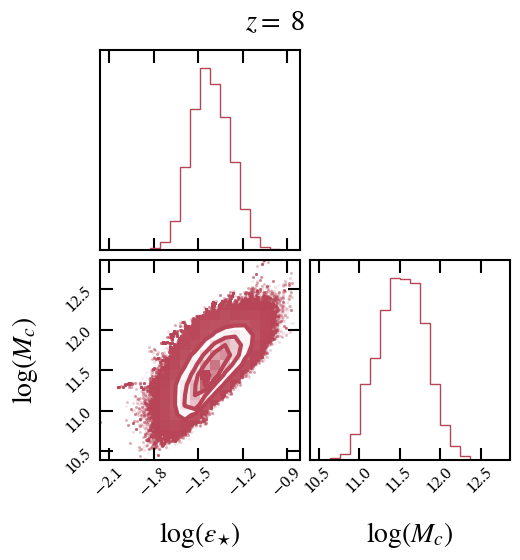

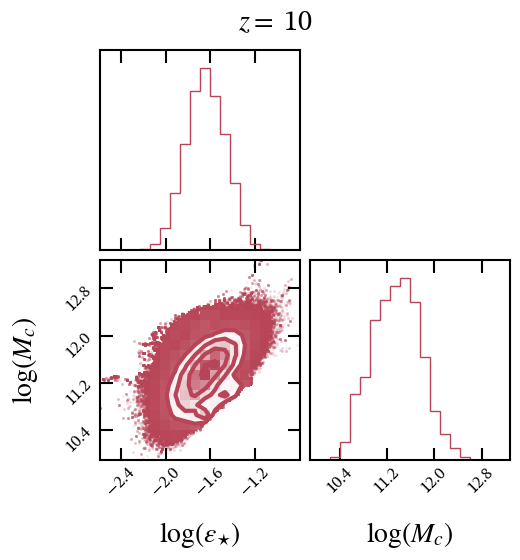

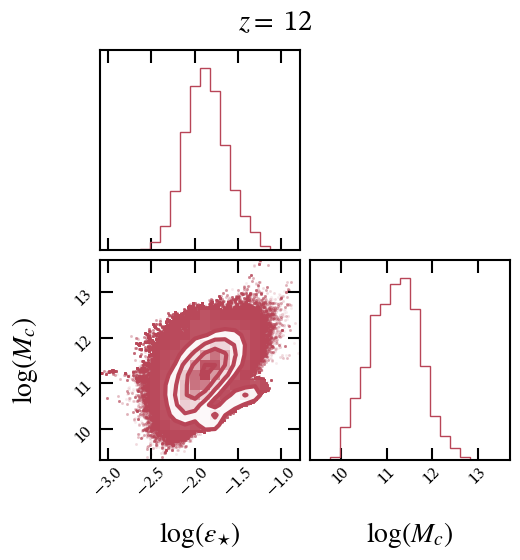

In [37]:
for z in [8, 10, 12]:
    epsz, Mcz = z_ev(z, eps, depsdz), z_ev(z, Mc, dMcdz)
    data = np.hstack([np.array(epsz).reshape(-1, 1), np.array(Mcz).reshape(-1, 1)])
    corner_plot = corner.corner(data, color = eplots.red, labels = [r'$\log(\epsilon_{\star})$', r'$\log(M_c)$'])
    corner_plot.suptitle(fr'$z = $ {z}', x = 0.5, y = 1)

    corner_plot.savefig(f'/Users/eb35267/Desktop/code/figures/corner_eps_Mc_{z}.png')

[0.8178944491541991, -0.03496732915029185, 11.973389873454773, 0.0434621108432867, -1.3894880901199227, -0.1457137257259224, 0.997914450441011, -0.7874411012492417, 0.6785357226165416]


/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:229: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:229: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


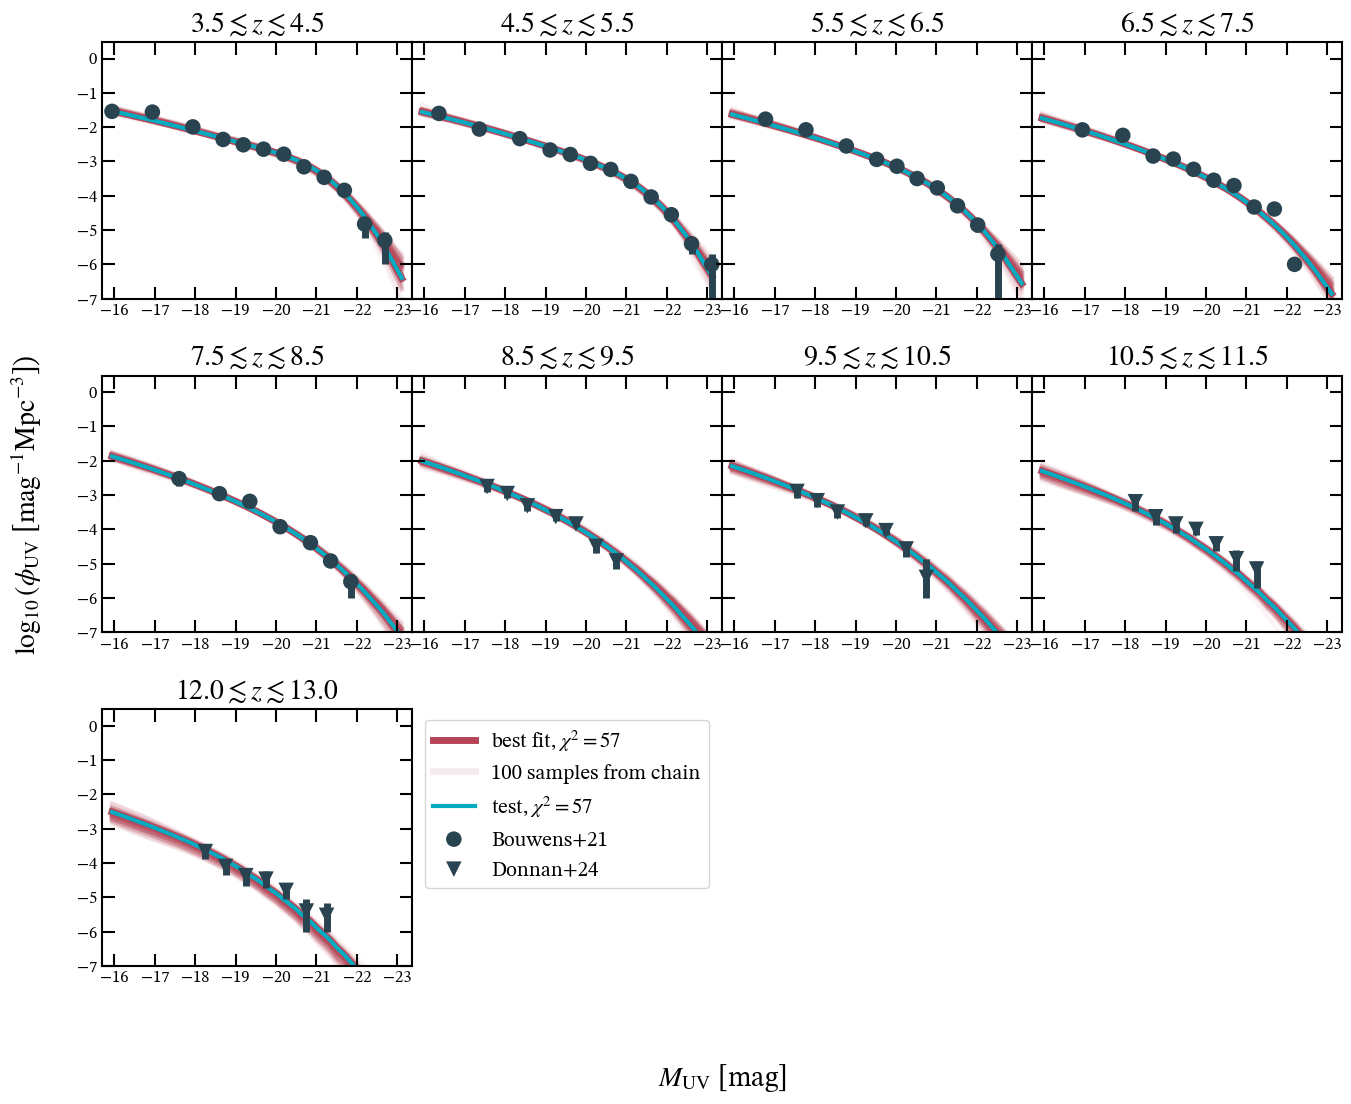

In [59]:
# UVLF plot
#test = [0.818, -0.035, 11.973, 0.043, -1.389, -0.146, 0.998, -0.787, 0.679]
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, backend_file = file_name, ncols = 4, comparison_fits = [test], comparison_labels = ['test'])

In [57]:
ev_fig.savefig(f'{folder}/evolving_UVLF.png', bbox_inches='tight')

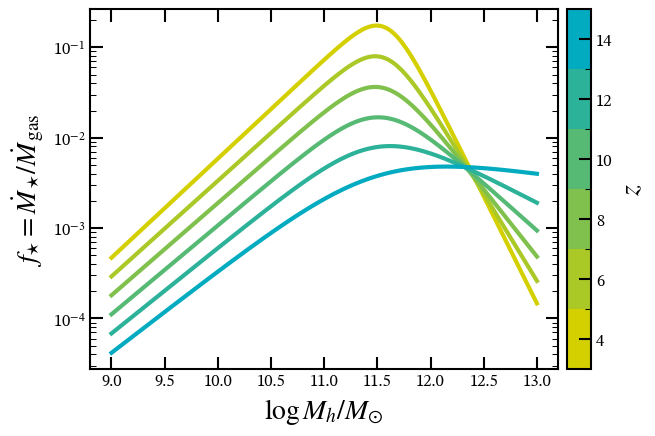

In [23]:
# SFE(Mh) for different z
sfe_over_mh, _ = eplots.sfe_shape_diff_z(my_UVLF, best_fit)
sfe_over_mh.savefig(f'{folder}/sfe_over_mh.png', bbox_inches = 'tight')

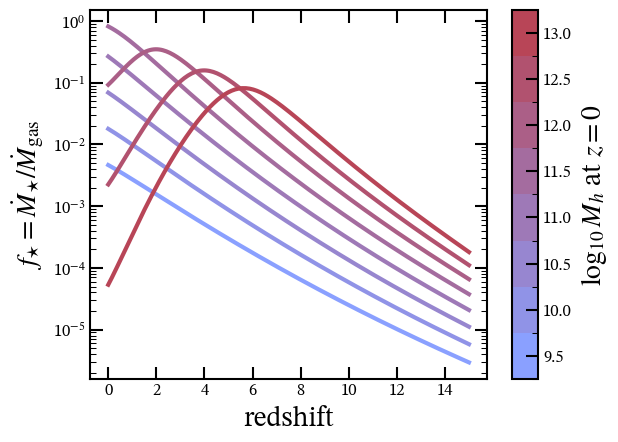

In [24]:
# SFE(z) for different Mh at z = 0
sfe_over_z = eplots.sfe_over_time(my_UVLF, best_fit)
sfe_over_z.savefig(f'{folder}/sfe_over_z.png', bbox_inches = 'tight')

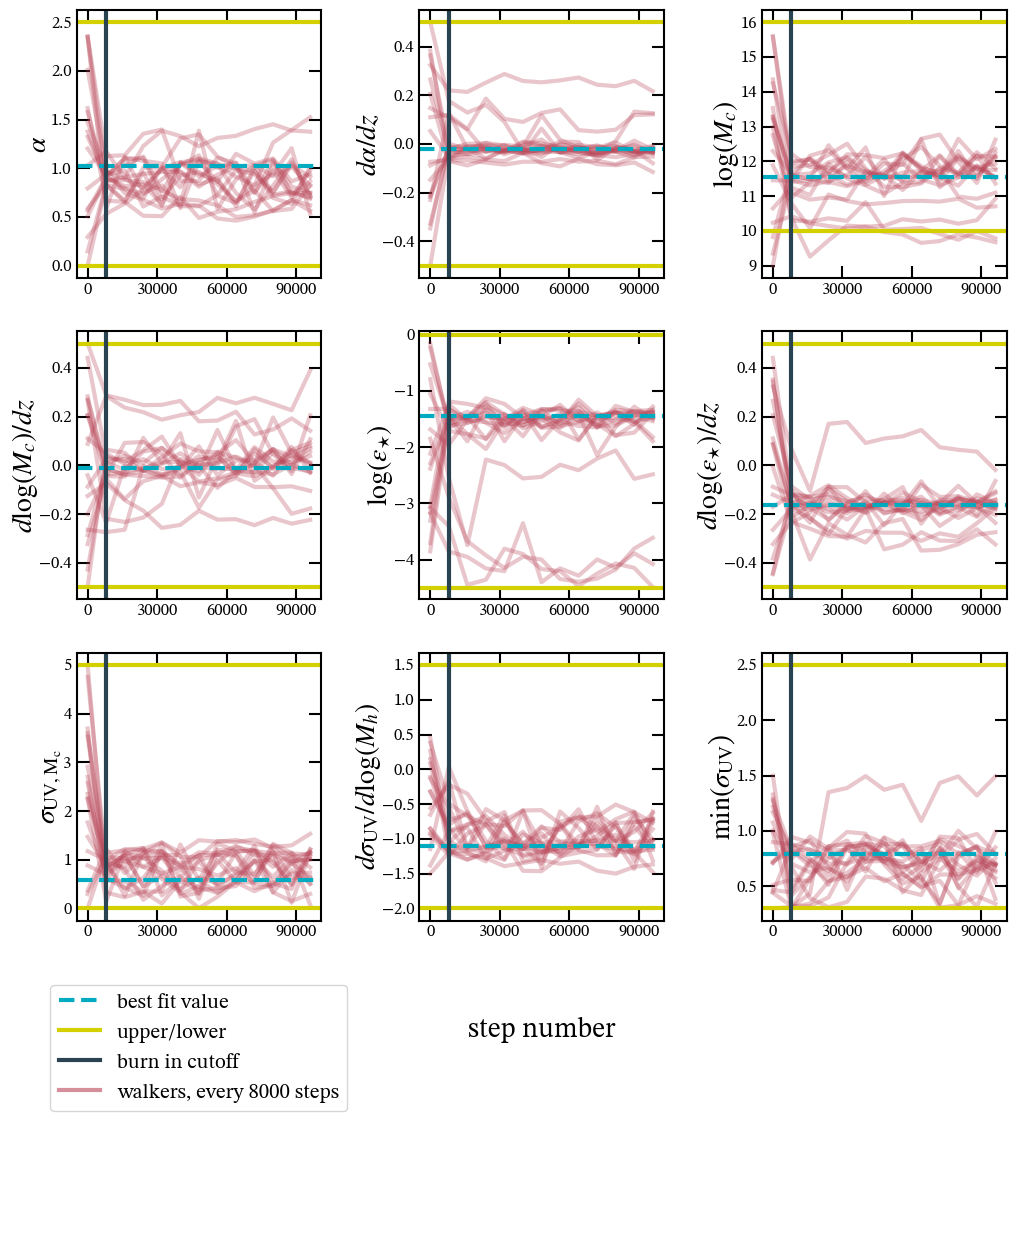

In [25]:
# Plot walkers & burn-in
walker_fig = eplots.walkers(my_UVLF, best_fit, backend_file = file_name)
walker_fig.savefig(f'{folder}/walkers.png', bbox_inches='tight')

In [58]:
table = eplots.make_table([best_fit], param_labels, ['best fit'], [bounds])
dfi.export(table, f'{folder}/table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

In [42]:
table

,best fit
$\alpha$,$0.388^{+0.09}_{-0.03}$
$d\alpha/dz$,$-0.075^{+0.03}_{-0.01}$
$\log(M_c)$,$12.051^{+0.17}_{-0.36}$
$d\log(M_c)/dz$,$0.083^{+0.03}_{-0.08}$
$\log(\epsilon_{\star})$,$-1.388^{+0.12}_{-0.12}$
$d\log(\epsilon_{\star})/dz$,$-0.127^{+0.03}_{-0.01}$
"$\sigma_{\rm{UV}, M_c}$",$0.754^{+0.12}_{-0.09}$


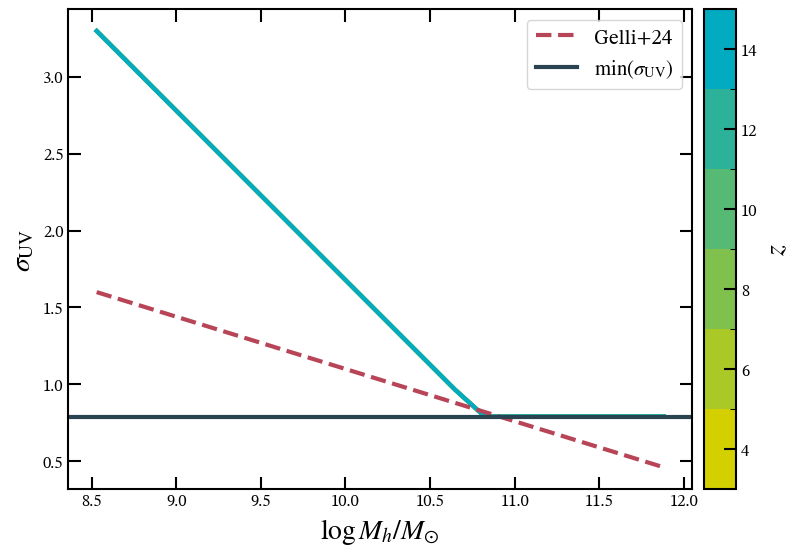

In [27]:
sigMh_fig = eplots.sigma_Mh(my_UVLF, best_fit)

In [28]:
sigMh_fig.savefig(f'{folder}/sigvsMh.png', bbox_inches='tight')

# Comparison plots (old)

In [ ]:
params = eMCMC.build_param_data({})
my_UVLF = eMCMC.UVLF(sorted_data, params)
fix_beta_fit = []
limited_fit = [0.85, 0.06, -0.54, 0, 11.79, 0, -0.93, -0.04, 0.16, 0.18, -0.88]
full_fit = [0.99, 0.08, -0.22, 0.28, 10.72, -0.32, -1.94, -0.22, 1.06, -0.06, -0.56]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:186: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:186: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/

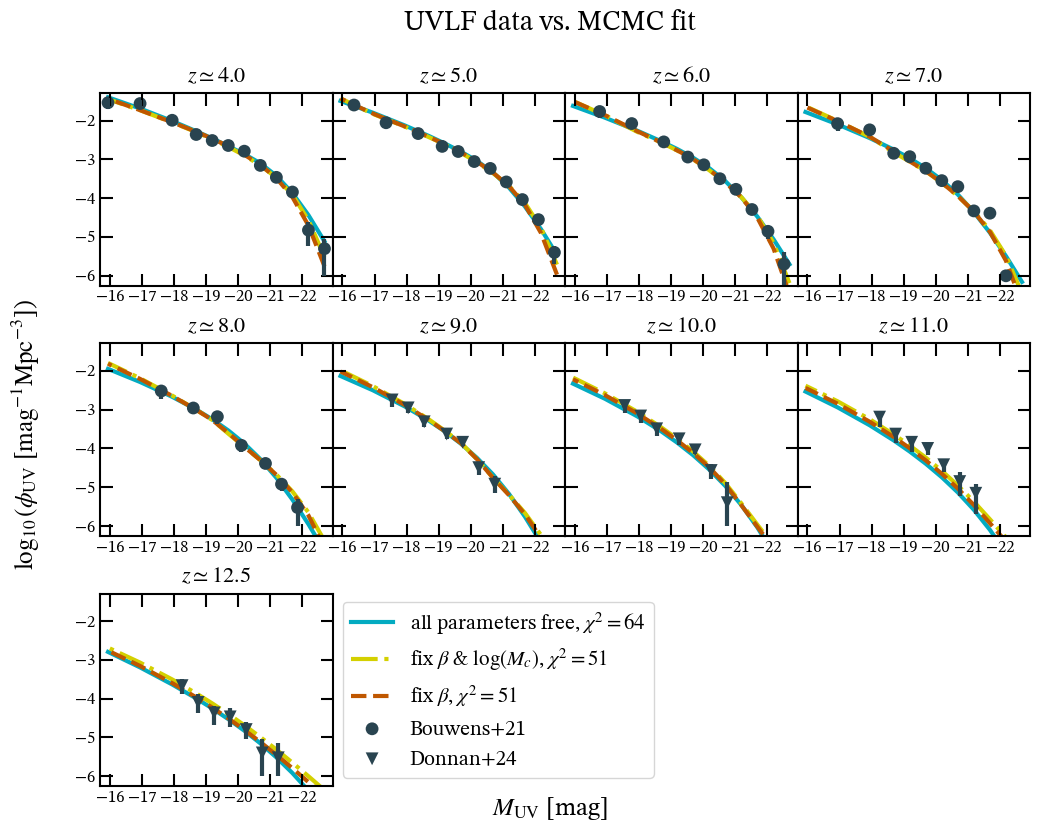

In [183]:
comparison_plot = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [full_fit, limited_fit, fix_beta_fit], 
                                           comparison_labels=['all parameters free', r'fix $\beta$ & $\log(M_c)$', r'fix $\beta$'], ncols = 4)

In [186]:
my_UVLF.get_fit??

Signature:
my_UVLF.get_fit(
    backend_file=None,
    burn_in=None,
    exclude_unfit=True,
    excluded_params=[],
)
Source:   
    def get_fit(self, backend_file = None, burn_in = None, exclude_unfit = True, excluded_params = []):
        """
        Get samples and best fit values from MCMC samples (or, if the parameter is not fit, return the default value).
        Inputs:
            backend_file [str]: .h5 file containing previously saved chain
            burn_in [int]: number of steps to discard as burnin
            exclude_unfit [bool]: whether or not to exclude parameters that are set by default (and not by the MCMC chain) 
            excluded_params [list]: any parameters you don't want to return
        Outputs:
            samples [Ndarray]: MCMC chain samples
            best_fit [list]: ordered list of best fit parameters (or default parameters where applicable)
            bounds [Nx2 array]: Upper and lower bounds on parameter values that correspond to the 16th & 84

In [204]:
param_labels = my_UVLF.param_data['label'].values
comparison_table = eplots.make_table([full_fit, fix_beta_fit, limited_fit], param_labels, 
                                     ['all parameters free', r'fix $\beta$', r'fix $\beta$ & $\log(M_c)$'], bounds = [None, None, None])

In [207]:
dfi.export(comparison_table, '/Users/eb35267/Desktop/code/home/figures/comparison_table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

In [40]:
def plot_walkers(walkers, thin, fits, fit_labels, ncols = 3):
    steps = np.arange(0, len(walkers[:,0][:,0]), thin)
    walkers = walkers[0::thin]
    nparams = walkers.shape[-1]
    fig = plt.figure()
    fig.set_size_inches(3*ncols, 3*math.ceil((nparams+1)/ncols))
    plt.subplots_adjust(wspace = 0.4, hspace = 0.2)
    gs = GridSpec(math.ceil((nparams+1)/ncols), ncols, figure=fig)
    
    for i in range(nparams):
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        for j in range(len(walkers[i])):
            ax.plot(steps, walkers[:,j][:,i], color = eplots.red, ls = '-', alpha = 0.3)
        for fit, fit_label, color, ls in zip(fits, fit_labels, 
                                             [eplots.turquoise, eplots.yellow], ['-', 'dashdot']):
            ax.axhline(fit[i], color = color, ls = ls, label = fit_label)
        ax.set_ylabel(fr'{my_UVLF.param_data['label'][my_UVLF.param_data['fit'].values.astype(bool)].iloc[i]}', labelpad = -0.6)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.axvline(8000, color = eplots.navy, ls = '-', label = 'burn in cutoff')
    
    ax.plot(0,0, color = eplots.red, ls = '-', alpha = 0.6, label = f'walkers, every {thin} steps') # get label
    fig_ax = fig.add_subplot(gs[math.floor((i+1)/ncols), (i+1)%ncols])
    fig_ax.axis("off")  
    handles, labels = ax.get_legend_handles_labels() # Grab handles/labels from the real axes
    fig_ax.legend(handles, labels, loc='center')
    fig.supxlabel('step number', y = 0.05)
    
    return fig

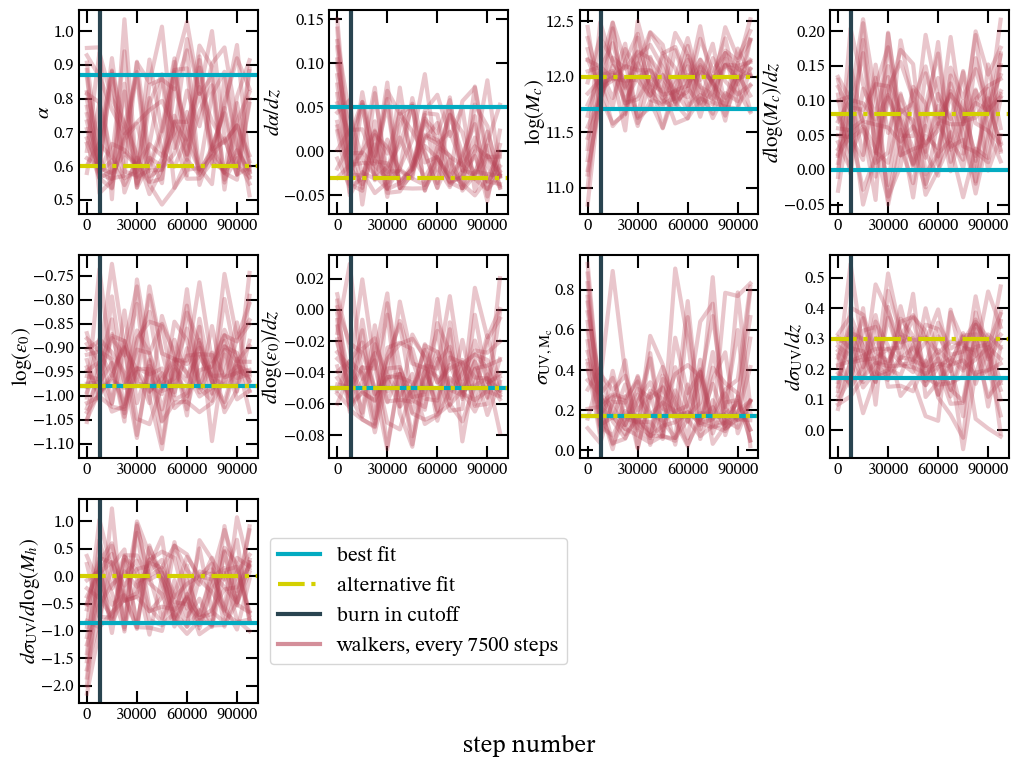

In [41]:
reader = emcee.backends.HDFBackend(file_name)
walkers = reader.get_chain(discard = 0)
best_fit = [0.87, 0.05, 11.71, 0, -0.98, -0.05, 0.17, 0.17, -0.86]
other_fit = [.6, -0.03, 12, 0.08, -0.98, -0.05, 0.17, 0.3, 0]
walker_plot = plot_walkers(walkers, thin = 7500, fits = [best_fit, other_fit], 
                           fit_labels = ['best fit', 'alternative fit'], ncols = 4)

In [37]:
walker_plot.savefig('/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/walker_plot.png', bbox_inches = 'tight')

In [164]:
from astropy import constants as c
from astropy import units as u
(1.202/np.pi**2) * (3/4)

0.0913410470535675

In [41]:
default_df = my_UVLF.param_data

In [79]:
default_df

,fit,value,lower,upper,label
alpha,True,0.6,0,4,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,False,-0.54,-3,0,$\beta$
dbetadz,False,0,-1,1.5,$d\beta/dz$
logMc,True,12,9,16,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-4.5,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.5,1,$d\sigma_{\rm{UV}}/dz$


In [23]:
sigMh_fig.savefig(f'{folder}/sigvsMh.png', bbox_inches = 'tight')

# Old stuff (Muñoz+23 comparison)

In [ ]:
# # Parameter table
# table = eplots.make_table([best_fit, munoz_fit_vary_eps, munoz_fit_vary_sig], param_labels, ['best fit', r'Muñoz+23 piecewise $\epsilon_0$', 
#                                                                                              r'Muñoz+23 piecewise $\sigma_{\rm{UV}}$'], 
#                           [bounds, None, None])
# dfi.export(table, f'{folder}/table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

In [ ]:
# sorted_data = edata.get_sorted(file_names, data_labels, include_zs = [4, 5, 6, 7, 8, 9])

Skipping $z = 10.0


In [ ]:
# params = eMCMC.build_param_data({})
# new_UVLF = eMCMC.UVLF(sorted_data, param_data = params)

In [ ]:
# best_fit_old = [0.67, 0, -1.2, 0, 12.11, 0, -0.82, 0, 0.03, 0, 0.31]
# best_fit_new = [0.54, -0.01, -0.81, 0.55, 11.74, -0.03, -1.28, -0.1, 0.64, -0.02, 0]
# munoz_fit_1 = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, -1, 0, 0.65, -0.03, 0]
# munoz_fit_2 = [0.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, 0.75, 0, 0]

/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',


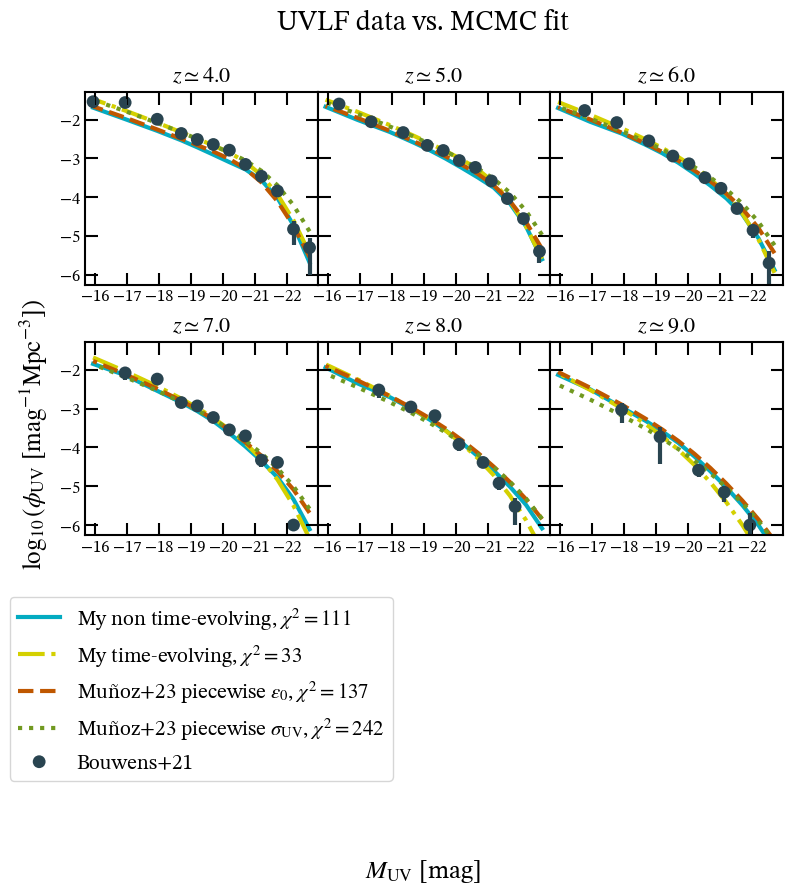

In [ ]:
# # UVLF plot
# ev_fig = eplots.evolving_UVLF_fit(new_UVLF, plot_from_chain = False, comparison_fits = [best_fit_old, best_fit_new, munoz_fit_1, munoz_fit_2],
#                                   comparison_labels = ['My non time-evolving', 'My time-evolving', r'Muñoz+23 piecewise $\epsilon_0$', r'Muñoz+23 piecewise $\sigma_{\rm{UV}}$'])
# #ev_fig.savefig(f'{folder}/evolving_UVLF_fit_comparison.png', bbox_inches = 'tight')